Deliverables of Module 2

✅ Treatment rate

✅ Outcome comparison

✅ Selection bias evidence

✅ Specialty analysis

✅ Tier analysis

✅ Correlation analysis

✅ Executive insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

Matplotlib is building the font cache; this may take a moment.


In [2]:
hcp_df = pd.read_csv("../data/raw/hcp_data.csv")

hcp_df.head()


,hcp_id,specialty,tier,years_practice,historical_email_opens,historical_msl_calls,digital_engagement_score,publication_downloads,webinar_attendance,treatment,scientific_score
0,100001,Oncology,B,20,9,1,58.793176,7,1,0,79.668516
1,100002,Endocrinology,B,16,4,1,66.438587,1,1,1,42.075132
2,100003,Neurology,A,13,11,2,46.190995,1,1,1,63.274922
3,100004,Cardiology,B,24,4,1,71.897680,6,4,1,92.253449
4,100005,Oncology,B,14,7,2,72.013108,4,3,0,72.194866


In [3]:
hcp_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   hcp_id                    10000 non-null  int64  
 1   specialty                 10000 non-null  object 
 2   tier                      10000 non-null  object 
 3   years_practice            10000 non-null  int64  
 4   historical_email_opens    10000 non-null  int64  
 5   historical_msl_calls      10000 non-null  int64  
 6   digital_engagement_score  10000 non-null  float64
 7   publication_downloads     10000 non-null  int64  
 8   webinar_attendance        10000 non-null  int64  
 9   treatment                 10000 non-null  int64  
 10  scientific_score          10000 non-null  float64
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [4]:
hcp_df.describe()

,hcp_id,years_practice,historical_email_opens,historical_msl_calls,digital_engagement_score,publication_downloads,webinar_attendance,treatment,scientific_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,17.931600,7.992500,1.992500,60.058035,2.993900,2.009700,0.262600,69.112097
std,2886.89568,9.432074,2.806356,1.404507,15.046378,1.723473,1.403995,0.440069,14.725531
min,100001.00000,2.000000,0.000000,0.000000,4.483420,0.000000,0.000000,0.000000,14.091626
25%,102500.75000,10.000000,6.000000,1.000000,49.903211,2.000000,1.000000,0.000000,59.051699
50%,105000.50000,18.000000,8.000000,2.000000,60.243516,3.000000,2.000000,0.000000,68.769648
75%,107500.25000,26.000000,10.000000,3.000000,70.006252,4.000000,3.000000,1.000000,78.814672
max,110000.00000,34.000000,23.000000,8.000000,100.000000,13.000000,9.000000,1.000000,129.745882


In [5]:
hcp_df["treatment"].value_counts(normalize=True)

treatment
0    0.7374
1    0.2626
Name: proportion, dtype: float64

In [6]:
hcp_df["specialty"].value_counts()


specialty
Oncology         4582
Cardiology       2021
Neurology        1949
Endocrinology    1448
Name: count, dtype: int64

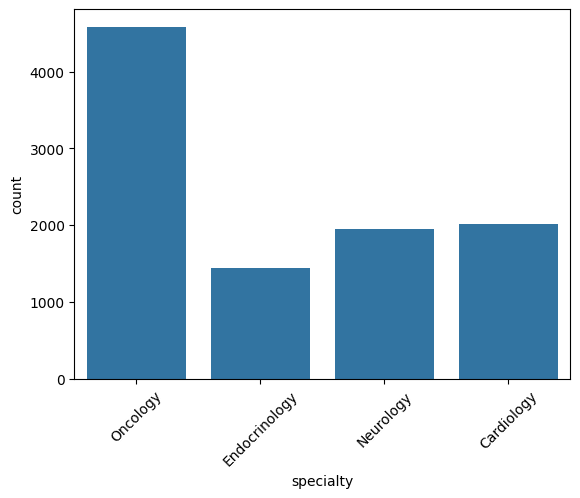

In [7]:
sns.countplot(
    data=hcp_df,
    x="specialty"
)

plt.xticks(rotation=45)
plt.show()

treatment
0    7.906835
1    8.233054
Name: historical_email_opens, dtype: float64
-----------
treatment
0    1.973420
1    2.046078
Name: historical_msl_calls, dtype: float64
----------


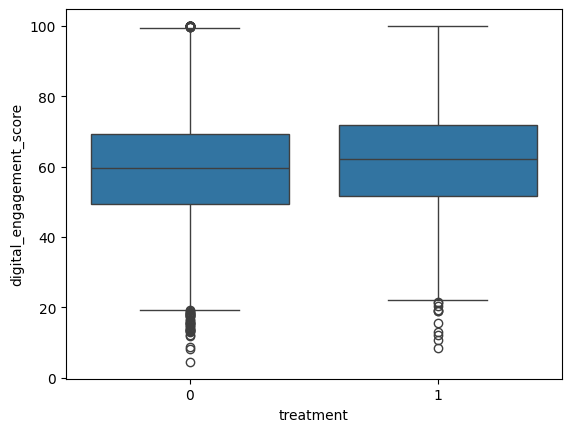

In [12]:
print(hcp_df.groupby(
    "treatment"
)["historical_email_opens"].mean())
print("-----------")
print(hcp_df.groupby(
    "treatment"
)["historical_msl_calls"].mean())
print("----------")
hcp_df.groupby(
    "treatment"
)["digital_engagement_score"].mean()

sns.boxplot(
    data=hcp_df,
    x="treatment",
    y="digital_engagement_score"
)

plt.show()

In [13]:
hcp_df.groupby(
    "treatment"
)["scientific_score"].mean()

treatment
0    66.591118
1    76.191190
Name: scientific_score, dtype: float64

In [14]:
76 - 66 

10

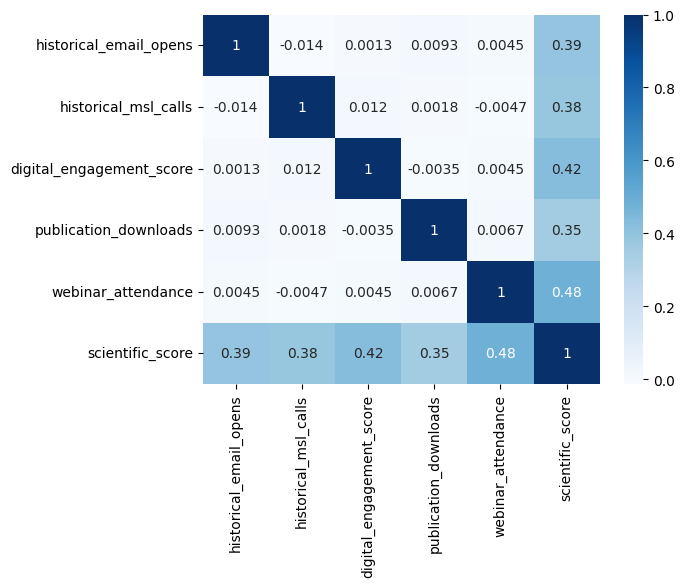

In [15]:
numeric_cols = [
    "historical_email_opens",
    "historical_msl_calls",
    "digital_engagement_score",
    "publication_downloads",
    "webinar_attendance",
    "scientific_score"
]

corr = hcp_df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.show()

treatment             0         1
specialty                        
Cardiology     0.742702  0.257298
Endocrinology  0.726519  0.273481
Neurology      0.721909  0.278091
Oncology       0.745089  0.254911
-----------


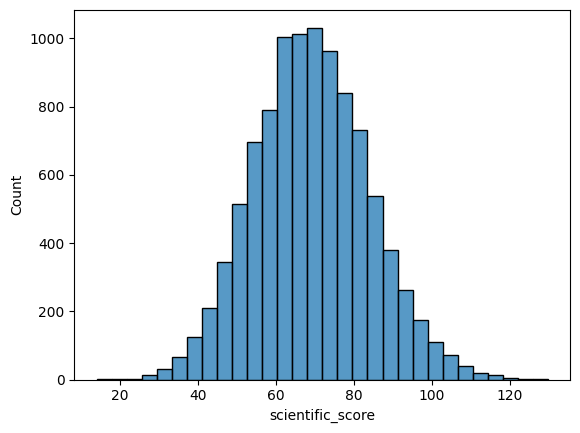

In [18]:
print(pd.crosstab(
    hcp_df["specialty"],
    hcp_df["treatment"],
    normalize="index"
))

print("-----------")

pd.crosstab(
    hcp_df["tier"],
    hcp_df["treatment"],
    normalize="index"
)

sns.histplot(
    hcp_df["scientific_score"],
    bins=30
)

plt.show()


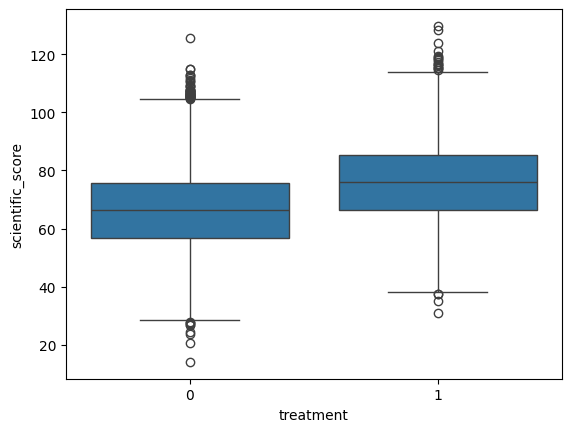

In [19]:
sns.boxplot(
    data=hcp_df,
    x="treatment",
    y="scientific_score"
)

plt.show()

In [20]:
print("""
KEY INSIGHTS:

1. Treated HCPs have higher historical engagement.
2. Treated HCPs receive more MSL interactions.
3. Scientific scores are higher in treated groups.
4. Significant selection bias exists.
5. Direct comparison is misleading.
6. Propensity score modeling is required.
""")


KEY INSIGHTS:

1. Treated HCPs have higher historical engagement.
2. Treated HCPs receive more MSL interactions.
3. Scientific scores are higher in treated groups.
4. Significant selection bias exists.
5. Direct comparison is misleading.
6. Propensity score modeling is required.

